## **Imports**

In [7]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import regex as re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import shutil
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

## **The Data**

In [8]:
# load the data
# df = pd.read_csv("class_df.csv")

# df.head()

##########

# load the data
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    csv_path = '/content/drive/MyDrive/Research - Data Leakage/Data/class_df.csv'
else:
    csv_path = 'class_df.csv'

df = pd.read_csv(csv_path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII
0,0,I hope it’s okay to gently share something her...,0.000,1
1,1,The Hanover Company is NOW HIRING! Position: ...,0.000,1
2,2,[#spamton](https://www.facebook.com/hashtag/sp...,0.125,1
3,3,good day everyone! permission to post,0.000,0
4,4,Hiring!Freshers for IT & Non-IT Technologies w...,0.000,1


In [9]:
print(df.dtypes)
print(df["Label_Has_PII"].value_counts(normalize=True))

Original_DataFrame_Index      int64
Original_Text                object
Exposure_Score              float64
Label_Has_PII                 int64
dtype: object
Label_Has_PII
1    0.878663
0    0.121337
Name: proportion, dtype: float64


--- Character Length Distribution ---
count    15527.000000
mean       432.373865
std        532.735536
min          5.000000
25%        165.000000
50%        281.000000
75%        486.000000
max      11019.000000
Name: Original_Text, dtype: float64

--- Word Count Distribution ---
count    15527.000000
mean        62.177368
std         74.641059
min          1.000000
25%         24.000000
50%         40.000000
75%         71.000000
max       1804.000000
Name: Original_Text, dtype: float64


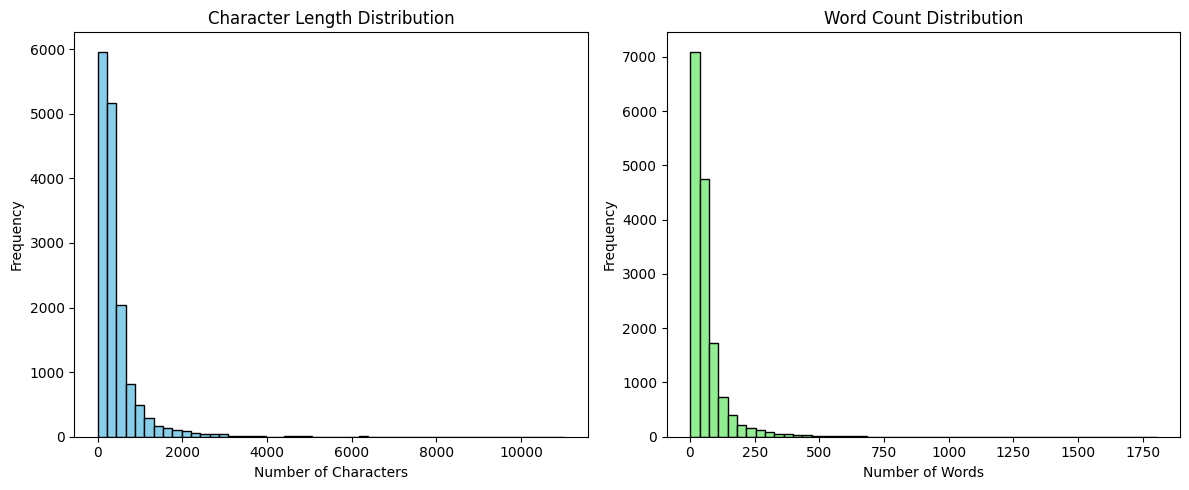

In [10]:
import matplotlib.pyplot as plt

# Calculate lengths
char_lengths = df["Original_Text"].apply(len)
word_lengths = df["Original_Text"].apply(lambda x: len(str(x).split()))

# Print statistics
print("--- Character Length Distribution ---")
print(char_lengths.describe())
print("\n--- Word Count Distribution ---")
print(word_lengths.describe())

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(char_lengths, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist(word_lengths, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## **Feature Engineering**

In [11]:
# ============================================================================
# FEATURE ENGINEERING  (+ dedup, + Exposure_Score dropped)
# ============================================================================
df = df.dropna(subset=["Original_Text", "Label_Has_PII"])
df["Original_Text"] = df["Original_Text"].astype(str)

# ---- DEDUP (before the split, to prevent train/test leakage) ---------------
n_before = len(df)
df = df.drop_duplicates(subset=["Original_Text"], keep="first").reset_index(drop=True)
print(f"Dedup: {n_before} -> {len(df)}  ({n_before - len(df)} duplicate texts removed)")
print("Label ratio after dedup:", df["Label_Has_PII"].value_counts(normalize=True).round(4).to_dict())

# ---- (A) Length & digit statistics ----------------------------------------
df['word_count']      = df['Original_Text'].str.split().str.len()
df['char_count']      = df['Original_Text'].str.len()
df['log_char_count']  = np.log1p(df['char_count'])
df['digit_count']     = df['Original_Text'].str.count(r'\d')
df['has_numbers']     = (df['digit_count'] > 0).astype(int)
df['non_digit_count'] = df['char_count'] - df['digit_count']
df['digits_non_digits_product'] = df['digit_count'] * df['non_digit_count']

# ---- (B) Structural PII patterns (regex) ----------------------------------
EMAIL_RE = re.compile(r'[A-Za-z0-9._%+\-]+@[A-Za-z0-9.\-]+\.[A-Za-z]{2,}')
PHONE_RE = re.compile(
    r'(?:\+\d{1,3}[\s.\-]?)?\(?\d{2,4}\)?[\s.\-]\d{2,4}[\s.\-]\d{2,4}(?:[\s.\-]\d{2,4})?'
)
df['email_count'] = df['Original_Text'].apply(lambda x: len(EMAIL_RE.findall(x)))
df['phone_count'] = df['Original_Text'].apply(lambda x: len(PHONE_RE.findall(x)))
df['has_email']   = (df['email_count'] > 0).astype(int)
df['has_phone']   = (df['phone_count'] > 0).astype(int)

# ---- Single source of truth ------------------------------------------------
# Exposure_Score DROPPED: corr with label = -0.028, means nearly identical
# across classes (0.467 vs 0.384). It contributes noise to the numeric branch.
NUMERIC_FEATURES = [
    'word_count',
    'char_count',
    'log_char_count',
    'has_numbers',
    'digit_count',
    'non_digit_count',
    'digits_non_digits_product',
    'email_count',
    'phone_count',
    'has_email',
    'has_phone',
]

print("\nNumeric features feeding the model:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES)
display(df[NUMERIC_FEATURES].describe())

Dedup: 15527 -> 15256  (271 duplicate texts removed)
Label ratio after dedup: {1: 0.8799, 0: 0.1201}

Numeric features feeding the model: 11
['word_count', 'char_count', 'log_char_count', 'has_numbers', 'digit_count', 'non_digit_count', 'digits_non_digits_product', 'email_count', 'phone_count', 'has_email', 'has_phone']


,word_count,char_count,log_char_count,has_numbers,digit_count,non_digit_count,digits_non_digits_product,email_count,phone_count,has_email,has_phone
count,15256.000000,15256.000000,15256.000000,15256.000000,15256.000000,15256.000000,1.525600e+04,15256.000000,15256.000000,15256.000000,15256.000000
mean,62.245018,433.138831,5.648596,0.729877,10.476009,422.662821,1.043051e+04,0.110776,0.072758,0.097535,0.066990
std,74.709863,533.324067,0.908536,0.444038,27.780168,521.206923,1.575136e+05,0.356132,0.288219,0.296695,0.250013
min,1.000000,5.000000,1.791759,0.000000,0.000000,3.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,24.000000,165.000000,5.111988,0.000000,0.000000,160.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,40.000000,281.000000,5.641907,1.000000,5.000000,274.000000,1.180000e+03,0.000000,0.000000,0.000000,0.000000
75%,71.000000,487.000000,6.190315,1.000000,12.000000,476.250000,4.500000e+03,0.000000,0.000000,0.000000,0.000000
max,1804.000000,11019.000000,9.307467,1.000000,1677.000000,10917.000000,1.516343e+07,4.000000,6.000000,1.000000,1.000000


## **Stratified Split & Directory Creation**

In [12]:
# ============================================================================
# STRATIFIED 3-WAY SPLIT  (train / val / test)
# ============================================================================
# Stratified on the label so the natural ~7:1 ratio is preserved in every split.
# After this point: any fitting (vectorizer adapt, scaler fit, class weights,
# oversampling) is done on TRAIN ONLY. val/test keep their natural distribution.
# ============================================================================

from sklearn.model_selection import train_test_split

CONFIG = {
    "batch_size": 32,
    "max_vocab_size": 30000,
    "max_seq_length": 130,
    "random_state": 42,
    "text_col": "Original_Text",
    "label_col": "Label_Has_PII",
}

# Split 1: (Train+Val) 85%  vs  Test 15%
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df[CONFIG['label_col']],
    random_state=CONFIG['random_state'],
)

# Split 2: from the 85%, carve out Val so final ratios are ~70/15/15.
# 0.1765 * 0.85 ≈ 0.15 of the total.
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    stratify=train_val_df[CONFIG['label_col']],
    random_state=CONFIG['random_state'],
)

# Reset positional index so text / numeric / labels stay row-aligned downstream.
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ---- Sanity checks ---------------------------------------------------------
print("Split sizes -> train:", len(train_df),
      "| val:", len(val_df), "| test:", len(test_df))

print("\nLabel ratio per split (should all be ≈ 0.88 / 0.12):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    ratios = d[CONFIG['label_col']].value_counts(normalize=True).round(3).to_dict()
    print(f"  {name:5s}: {ratios}")

Split sizes -> train: 10678 | val: 2289 | test: 2289

Label ratio per split (should all be ≈ 0.88 / 0.12):
  train: {1: 0.88, 0: 0.12}
  val  : {1: 0.88, 0: 0.12}
  test : {1: 0.88, 0: 0.12}


## **Text Vectorization**

In [13]:
# ============================================================================
# TEXT VECTORIZATION for EMBEDDINGS -- integer sequences
# ============================================================================
# STEMMER REMOVED. It was a Bag-of-Words artifact: it destroys morphology that
# an Embedding layer can learn on its own, and it is actively harmful for any
# future transformer (WordPiece expects raw text).
# ============================================================================

MAX_VOCAB_SIZE = CONFIG["max_vocab_size"]
MAX_SEQ_LENGTH = CONFIG["max_seq_length"]     # 71% of posts are <= 64 words, 90% <= 128

print("Preprocessing text per split (lowercase + punctuation spacing only)...")
PUNCT_RE = r'([!@#$%^&*(),.?":{}|<>])'

train_text = train_df[CONFIG["text_col"]].str.lower().str.replace(PUNCT_RE, r' \1 ', regex=True).values
val_text   = val_df[CONFIG["text_col"]].str.lower().str.replace(PUNCT_RE, r' \1 ', regex=True).values
test_text  = test_df[CONFIG["text_col"]].str.lower().str.replace(PUNCT_RE, r' \1 ', regex=True).values

# ---- Vectorizer: INT sequences, adapt on TRAIN only ------------------------
vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQ_LENGTH,
    standardize=None,
)
print("Adapting vectorizer on TRAIN text only...")
vectorize_layer.adapt(train_text)
vocab_size = len(vectorize_layer.get_vocabulary())
print("Vocabulary size after adapt:", vocab_size)

X_train_text = vectorize_layer(train_text)
X_val_text   = vectorize_layer(val_text)
X_test_text  = vectorize_layer(test_text)

y_train = train_df[CONFIG["label_col"]].values
y_val   = val_df[CONFIG["label_col"]].values
y_test  = test_df[CONFIG["label_col"]].values

print("\nShapes:")
print("  X_train_text:", X_train_text.shape)
print("  y_train:", y_train.shape)

Preprocessing text per split (lowercase + punctuation spacing only)...
Adapting vectorizer on TRAIN text only...
Vocabulary size after adapt: 30000

Shapes:
  X_train_text: (10678, 130)
  y_train: (10678,)
